# Data Understanding and Preparation
Covers **Stage 1 + 2.1.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided (no change):* `config.py`. 
- *Provided to extend:* `src/data_prep.py` (function stubs). 
- *You build:* this notebook + the report.

Prereqs: `pip install -r requirements.txt`; extract the Kaggle casting dataset under `data/` (train/test → ok_front/def_front).

### 0. Setup

In [1]:
import config
from src import data_prep
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import numpy as np
import collections
from collections import Counter
# TODO: print config.CLASS_TO_IDX and config.POSITIVE_CLASS to confirm setup
print("Class mapping:", config.CLASS_TO_IDX)
print("Positive class:", config.POSITIVE_CLASS)

Class mapping: {'ok_front': 0, 'def_front': 1}
Positive class: def_front


## **Stage 1.1 — Business & Data Understanding** <font color="red">[5 marks]</font>

- **1.1.1 — Business objective & justification [2]** — *to be done in the report*
- **1.1.2 — Success metric choice (recall/F1 on defects) [2]** — *to be done in the report*
- **1.1.3 — Dataset structure & class understanding [1]**

**Objective:** Understand the problem + dataset and name the right metric.

**Implement in:** this notebook (+ src/data_prep.find_data_root, list_images)

**Inputs → Outputs:** data/ images → counts + class distribution per split

**TODO:** locate the data root; count images per class per split; plot the distribution; state that defect = positive class and recall-on-defects (not accuracy) is the headline metric.

**Document here:** 1.1.1/1.1.2 in the report; 1.1.3 here (dataset structure).

       ok_front  def_front
train      2875       3758
test        262        453


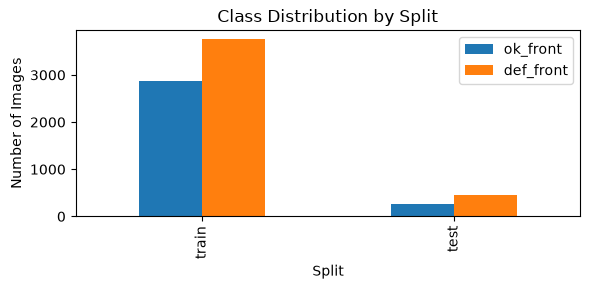

In [2]:
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split


root = data_prep.find_data_root()

counts = {}
for split in ["train", "test"]:
    items = data_prep.list_images(root / split)
    c = collections.Counter(config.IDX_TO_CLASS[i] for _, i in items)
    counts[split] = dict(c)

dist = pd.DataFrame(counts).T
print(dist)

dist.plot.bar(figsize=(6, 3))
plt.title("Class Distribution by Split")
plt.xlabel("Split")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## **Stage 1.2 — Data Quality Validation** <font color="red">[5 marks]</font>

- **1.2.1 — Corrupt-file & image-dimension checks [2]**
- **1.2.2 — Duplicate detection (hashing) — leakage guard [2]**
- **1.2.3 — Class distribution + pass/fail report [1]**

**Objective:** Programmatically validate image quality before any split.

**Implement in:** src/data_prep.validate_quality

**Inputs → Outputs:** data root → a pass/fail report dict (corrupt, duplicates, dimensions, distribution)

**TODO:** check missing/corrupt files (Image.verify) and dimensions (1.2.1); detect DUPLICATE images via md5/hash (1.2.2); quantify class balance + print a pass/fail report (1.2.3); expect ~7,348 images, ~64 duplicates.

**Document here:** the quality report + why duplicate detection prevents train/test leakage.

In [3]:
# TODO 1.2.1-1.2.3: qc = data_prep.validate_quality(root); print(qc['total_images'], qc['passed'])
qc = data_prep.validate_quality(root)

print("Total Images :", qc["total_images"])
print("Quality Passed :", qc["passed"])

print("\nQuality Report")
for k, v in qc["issues"].items():
    print(f"{k}: {v}")

Total Images : 7348
Quality Passed : True

Quality Report
corrupt_files: []
duplicate_pairs: [('cast_ok_0_1001.jpeg', 'cast_ok_0_1001.jpeg'), ('cast_ok_0_1002.jpeg', 'cast_ok_0_1002.jpeg'), ('cast_ok_0_1003.jpeg', 'cast_ok_0_1003.jpeg'), ('cast_ok_0_1019.jpeg', 'cast_ok_0_1019.jpeg'), ('cast_ok_0_1020.jpeg', 'cast_ok_0_1020.jpeg'), ('cast_ok_0_1021.jpeg', 'cast_ok_0_1021.jpeg'), ('cast_ok_0_1022.jpeg', 'cast_ok_0_1022.jpeg'), ('cast_ok_0_1026.jpeg', 'cast_ok_0_1026.jpeg'), ('cast_ok_0_1028.jpeg', 'cast_ok_0_1028.jpeg'), ('cast_ok_0_1031.jpeg', 'cast_ok_0_1031.jpeg'), ('cast_ok_0_1040.jpeg', 'cast_ok_0_1040.jpeg'), ('cast_ok_0_1066.jpeg', 'cast_ok_0_1066.jpeg'), ('cast_ok_0_1069.jpeg', 'cast_ok_0_1069.jpeg'), ('cast_ok_0_1077.jpeg', 'cast_ok_0_1077.jpeg'), ('cast_ok_0_1088.jpeg', 'cast_ok_0_1088.jpeg'), ('cast_ok_0_1092.jpeg', 'cast_ok_0_1092.jpeg'), ('cast_ok_0_1093.jpeg', 'cast_ok_0_1093.jpeg'), ('cast_ok_0_1095.jpeg', 'cast_ok_0_1095.jpeg'), ('cast_ok_0_1096.jpeg', 'cast_ok_0_1096.jp

## **Stage 1.3 — Dataset Versioning & Metadata** <font color="red">[5 marks]</font>

- **1.3.1 — Reproducible, stratified train/val/test split [3]**
- **1.3.2 — Split snapshot + metadata.json (versioning) [2]**

**Objective:** Create reproducible, versioned splits.

**Implement in:** src/data_prep.build_splits

**Inputs → Outputs:** data root + version id → train/val/test file lists + metadata.json

**TODO:** make a STRATIFIED train/val/test split (seed 42) (1.3.1); snapshot the file lists + write metadata.json (version id, date, class defs, split sizes, seed) (1.3.2).

**Document here:** the split sizes + the metadata record.

In [4]:
# TODO 1.3.1-1.3.2: meta = data_prep.build_splits(root, 'v1'); print(meta['split_info'])
meta = data_prep.build_splits(root, "v1")
print(meta["split_info"])

{'train': {'count': 5639}, 'val': {'count': 994}, 'test': {'count': 715}}


## **Stage 1.4 — EDA & Methodology Design** <font color="red">[5 marks]</font>

- **1.4.1 — Image-characteristic EDA [3]** — *to be done in this notebook and the report*
- **1.4.2 — End-to-end MLOps workflow design [2]** — *to be done in the report*

**Objective:** Explore image characteristics that motivate preprocessing + drift features.

**Implement in:** this notebook (+ src/data_prep.image_features)

**Inputs → Outputs:** sample images → a feature table (brightness/contrast/edge/sharpness/dark-ratio) by class

**TODO:** show a sample grid (OK vs Defective) + per-class feature means (1.4.1); in the report, design the end-to-end MLOps workflow (1.4.2).

**Document here:** an interpretation cell (1.4.1) + the workflow design in the report (1.4.2).

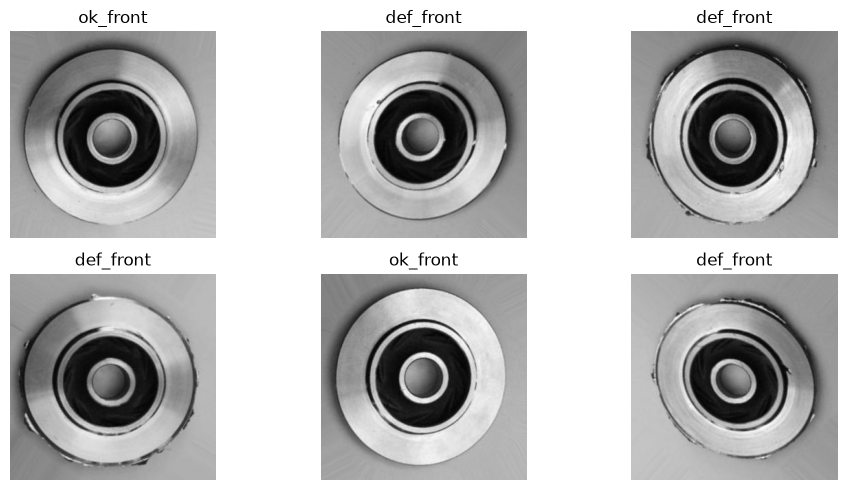

Number of training images: 5639
Average width : 300.0
Average height: 300.0


In [5]:
# TODO 1.4.1: sample-image grid; per-class image_features means
items = data_prep.load_split("v1", "train", root)

plt.figure(figsize=(10, 5))

for i, (path, label) in enumerate(items[:6]):
    plt.subplot(2, 3, i + 1)

    img = Image.open(path).convert("L")
    plt.imshow(img, cmap="gray")
    plt.title(config.IDX_TO_CLASS[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Basic statistics only
widths = []
heights = []

for path, _ in items:
    with Image.open(path) as img:
        widths.append(img.width)
        heights.append(img.height)

print("Number of training images:", len(items))
print("Average width :", np.mean(widths))
print("Average height:", np.mean(heights))

## **Stage 2.1 — Preprocessing & Augmentation** <font color="red">[6 marks]</font>

- **2.1.1 — Convert greyscale image to 3-channel RGB, resize 224, ImageNet normalise [3]**
- **2.1.2 — Train-only augmentation (val/test none) [3]**

**Objective:** Build transforms that match the pretrained ResNet18 backbone.

**Implement in:** src/data_prep.get_transforms

**Inputs → Outputs:** a PIL image → a (3,224,224) normalised tensor; train transform adds augmentation

**TODO:** Convert greyscale image to 3-channel RGB, Resize 224, ImageNet normalise (2.1.1); train-time augmentation (flip/rotation/translate/colour jitter) with val/test NO augmentation (2.1.2).

**Document here:** a before/after visualisation of the transforms.

In [6]:
# TODO 2.1.1-2.1.2: tf=data_prep.get_transforms(train=True); verify a sample tensor is (3,224,224)

tf = data_prep.get_transforms(train=True)

items = data_prep.load_split("v1", "train", root)
img_path, label = items[0]

img = Image.open(img_path).convert("L")
tensor = tf(img)

print("Tensor shape:", tensor.shape)
print("Label:", config.IDX_TO_CLASS[label])

Tensor shape: torch.Size([3, 224, 224])
Label: ok_front


---
**Outputs feed Stage 2.2+** in `Model_Development_and_Tracking.ipynb` (the versioned splits + transforms are reused to train the model).